# Exercise 1: Decision Tree - Age and Income predicting House Purchase

In this scenario, the data splits according to age and income to determine whether someone buys a house. If 70% of people over age 30 bought a house, then age becomes the first node, making the data 80% pure. The second node addresses income.

In [1]:
# CH.SC.U4CSE24119 Kavin JS

import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## Create Synthetic Dataset

The rule: people over 30 are more likely to buy a house (70% of them do). Income provides the second split.

In [2]:
import numpy as np
np.random.seed(42)

n = 200
age = np.random.randint(20, 60, n)
income = np.random.randint(20000, 120000, n)

# 70% of age > 30 buy; 30% of age <= 30 buy
buys = []
for a, i in zip(age, income):
    if a > 30:
        buys.append(1 if np.random.random() < 0.7 else 0)
    else:
        buys.append(1 if np.random.random() < 0.3 else 0)

data = pd.DataFrame({'age': age, 'income': income, 'buys': buys})
print(data.head(10))
print("\nClass distribution:")
print(data['buys'].value_counts())

   age  income  buys
0   58   62107     0
1   48  106202     1
2   34   71663     1
3   27   35708     0
4   40  111906     1
5   58   69811     1
6   38   22811     0
7   42   76250     0
8   30   92082     1
9   30   54754     0

Class distribution:
buys
1    113
0     87
Name: count, dtype: int64


## Train Decision Tree

In [3]:
x = data[['age', 'income']]
y = data['buys']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=5)

model = DecisionTreeClassifier(criterion='entropy', random_state=5, max_depth=4)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

## Print Decision Tree Rules

In [4]:
print(export_text(model, feature_names=['age', 'income']))

|--- age <= 30.50
|   |--- age <= 25.50
|   |   |--- age <= 22.50
|   |   |   |--- income <= 34850.00
|   |   |   |   |--- class: 1
|   |   |   |--- income >  34850.00
|   |   |   |   |--- class: 0
|   |   |--- age >  22.50
|   |   |   |--- class: 0
|   |--- age >  25.50
|   |   |--- age <= 26.50
|   |   |   |--- income <= 80566.50
|   |   |   |   |--- class: 1
|   |   |   |--- income >  80566.50
|   |   |   |   |--- class: 0
|   |   |--- age >  26.50
|   |   |   |--- income <= 91176.50
|   |   |   |   |--- class: 0
|   |   |   |--- income >  91176.50
|   |   |   |   |--- class: 1
|--- age >  30.50
|   |--- income <= 95557.50
|   |   |--- income <= 81350.50
|   |   |   |--- income <= 76748.00
|   |   |   |   |--- class: 1
|   |   |   |--- income >  76748.00
|   |   |   |   |--- class: 1
|   |   |--- income >  81350.50
|   |   |   |--- income <= 86397.50
|   |   |   |   |--- class: 0
|   |   |   |--- income >  86397.50
|   |   |   |   |--- class: 0
|   |--- income >  95557.50
|   |   |-

## Visualize Decision Tree

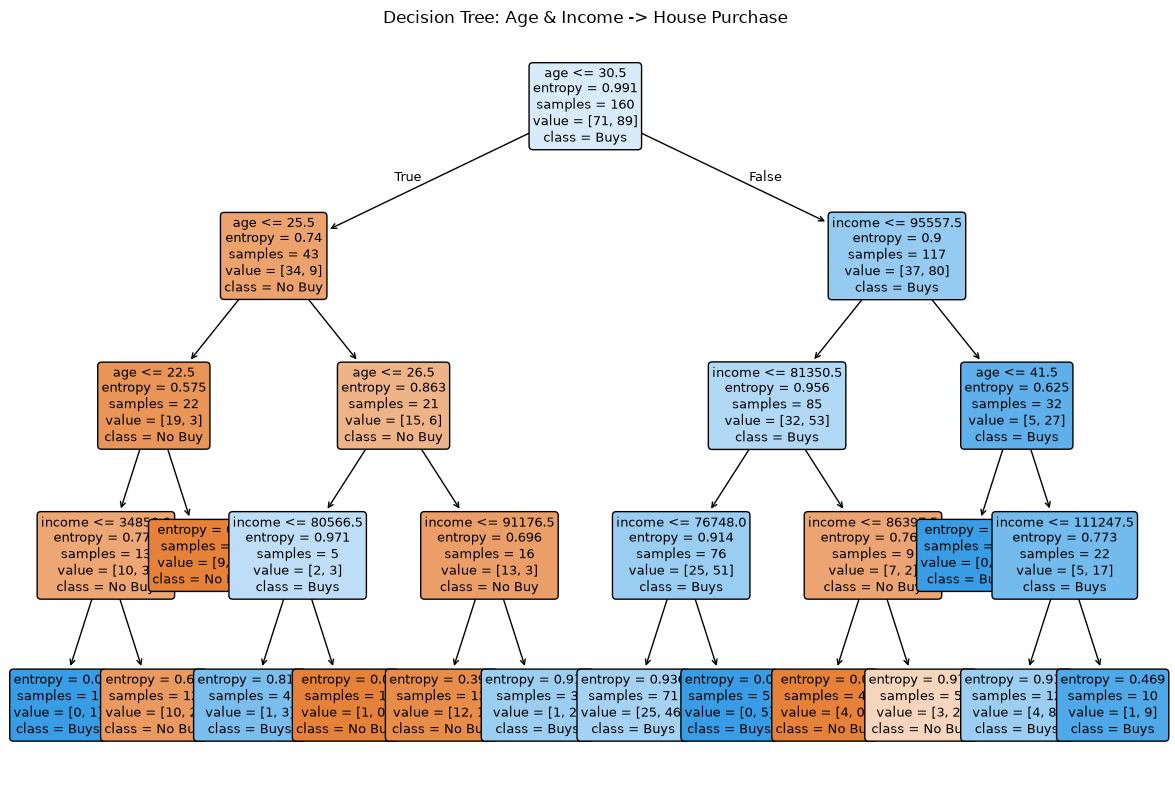

In [5]:
plt.figure(figsize=(12, 8))
plot_tree(model, feature_names=['age', 'income'], class_names=['No Buy', 'Buys'],
          filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree: Age & Income -> House Purchase')
plt.tight_layout()
plt.show()

## Accuracy

In [6]:
from sklearn import metrics
Accuracy_score = metrics.accuracy_score(y_test, y_pred)
print('Accuracy Score : ', Accuracy_score)
print('Accuracy in Percentage : ', int(Accuracy_score * 100), '%')

Accuracy Score :  0.675
Accuracy in Percentage :  67 %


## Conclusion

The first split in the tree is on **age** (around 30), which aligns with the rule that 70% of people over 30 buy a house. Income serves as the second splitting criterion to further purify the subsets.